# Copy-Paste Augmentation Analysis

This notebook analyzes the copy-paste augmentation results from experiment 07 (3-seed run).

**Analysis includes:**
- Number of new augmented images created  
- Number of objects pasted
- Distribution of object sizes (small, medium, large)
- Difficulty scores of new vs original objects and images

In [33]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define paths
PROJECT_ROOT = Path("/home/khanh/Projects/DifficultyAgri")
RESULTS_DIR = PROJECT_ROOT / "results" / "07_minneapple_yolo_full_3_seed"
# RESULTS_DIR = PROJECT_ROOT / "results" / "08_minneapple_yolo_full_random_3_seed"
SEEDS = ["seed_123", "seed_456", "seed_789"]

print(f"Project Root: {PROJECT_ROOT}")
print(f"Results Directory: {RESULTS_DIR}")
print(f"Analyzing seeds: {SEEDS}")

Project Root: /home/khanh/Projects/DifficultyAgri
Results Directory: /home/khanh/Projects/DifficultyAgri/results/07_minneapple_yolo_full_3_seed
Analyzing seeds: ['seed_123', 'seed_456', 'seed_789']


In [34]:
def load_scoring_results(seed_name):
    score_results_path = RESULTS_DIR / seed_name / "Step_3_Scoring_Dataset" / "score_results.json"
    with open(score_results_path, "r") as f:
        return json.load(f)

def load_dataset_properties(seed_name, dataset_type="initial"):
    if dataset_type == "initial":
        path = RESULTS_DIR / seed_name / "Step_1_Load_and_Validate_Dataset" / "dataset_properties.json"
    else:
        path = RESULTS_DIR / seed_name / "Step_4_Copy_Paste_Augmentation" / "dataset_properties.json"
    with open(path, "r") as f:
        return json.load(f)

# Load scoring results for all seeds
scoring_results_all_seeds = {}
for seed in SEEDS:
    scoring_results_all_seeds[seed] = load_scoring_results(seed)

# Load dataset properties
dataset_props_initial = {}
dataset_props_augmented = {}
for seed in SEEDS:
    dataset_props_initial[seed] = load_dataset_properties(seed, "initial")
    dataset_props_augmented[seed] = load_dataset_properties(seed, "augmented")

print(f"Loaded scoring results for {len(scoring_results_all_seeds)} seeds")

Loaded scoring results for 3 seeds


In [35]:
def count_augmented_images(seed_name):
    augmented_dataset_dir = RESULTS_DIR / seed_name / "Step_4_Copy_Paste_Augmentation" / "augmented_dataset" / "train" / "images"
    image_files = list(augmented_dataset_dir.glob("*.png")) + list(augmented_dataset_dir.glob("*.jpg"))
    augmented = [f for f in image_files if f.stem.startswith("aug_")]
    original = [f for f in image_files if not f.stem.startswith("aug_")]
    return {
        "total": len(image_files),
        "original": len(original),
        "augmented": len(augmented)
    }

# Count images for all seeds
aug_image_counts = {}
for seed in SEEDS:
    aug_image_counts[seed] = count_augmented_images(seed)

print("=" * 70)
print("AUGMENTED IMAGES CREATED")
print("=" * 70)
for seed, counts in aug_image_counts.items():
    print(f"\n{seed}:")
    print(f"  Original images (copied):      {counts['original']}")
    print(f"  NEW augmented images created:  {counts['augmented']}")
    print(f"  Total images in augmented set: {counts['total']}")
    print(f"  Dataset expansion ratio:       {counts['total'] / counts['original']:.2f}x")

# Average across seeds
avg_augmented = np.mean([c['augmented'] for c in aug_image_counts.values()])
avg_total = np.mean([c['total'] for c in aug_image_counts.values()])
print(f"\nAverage across {len(SEEDS)} seeds:")
print(f"  Average NEW augmented images:   {avg_augmented:.1f}")
print(f"  Average total dataset size:     {avg_total:.1f}")

AUGMENTED IMAGES CREATED

seed_123:
  Original images (copied):      536
  NEW augmented images created:  214
  Total images in augmented set: 750
  Dataset expansion ratio:       1.40x

seed_456:
  Original images (copied):      536
  NEW augmented images created:  214
  Total images in augmented set: 750
  Dataset expansion ratio:       1.40x

seed_789:
  Original images (copied):      536
  NEW augmented images created:  214
  Total images in augmented set: 750
  Dataset expansion ratio:       1.40x

Average across 3 seeds:
  Average NEW augmented images:   214.0
  Average total dataset size:     750.0


In [36]:
def categorize_object_by_size(width, height, image_width=None, image_height=None):
    '''Categorize object based on COCO evaluation standards (pixel area)
    
    COCO thresholds:
    - Small: area < 1024 (32×32 pixels)
    - Medium: 1024 ≤ area < 9216 (32×32 to 96×96 pixels)
    - Large: area ≥ 9216 (>= 96×96 pixels)
    
    Args:
        width, height: bounding box dimensions (normalized 0-1 if image dims not provided, else pixels)
        image_width, image_height: actual image dimensions in pixels (to convert from normalized)
    '''
    # Convert normalized to pixel dimensions if image size provided
    if image_width is not None and image_height is not None:
        width_px = width * image_width
        height_px = height * image_height
    else:
        # Assume coordinates are already in pixels or estimate from typical sizes
        width_px = width
        height_px = height
    
    area = width_px * height_px
    
    # COCO standard thresholds
    if area < 1024:
        return "small"
    elif area < 9216:
        return "medium"
    else:
        return "large"

def get_image_dimensions(image_path):
    '''Get image dimensions from file path'''
    try:
        import cv2
        img = cv2.imread(str(image_path))
        if img is not None:
            return img.shape[1], img.shape[0]  # width, height
    except:
        pass
    return None, None

def analyze_objects_in_labels_dir(labels_dir_path, augmented_dataset_dir):
    '''Analyze all objects in a labels directory with COCO-based sizing'''
    objects_stats = []
    
    labels_dir = Path(labels_dir_path)
    if not labels_dir.exists():
        return objects_stats
    
    augmented_images = {f.stem for f in list(augmented_dataset_dir.glob("aug_*.jpg")) + list(augmented_dataset_dir.glob("aug_*.png"))}
    
    for label_file in labels_dir.glob("*.txt"):
        image_name = label_file.stem
        is_augmented = image_name in augmented_images
        
        # Find corresponding image to get dimensions
        image_path = None
        for ext in ['.png', '.jpg', '.jpeg']:
            matches = list(augmented_dataset_dir.glob(f"{image_name}{ext}"))
            if matches:
                image_path = matches[0]
                break
        
        img_width, img_height = get_image_dimensions(image_path) if image_path else (None, None)
        
        with open(label_file, "r") as f:
            for obj_idx, line in enumerate(f):
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
                
                size_category = categorize_object_by_size(width, height, img_width, img_height)
                
                # Calculate area in pixels if possible
                if img_width and img_height:
                    area_px = (width * img_width) * (height * img_height)
                else:
                    area_px = width * height
                
                objects_stats.append({
                    "image_name": image_name,
                    "image_label_file": label_file.name,
                    "is_augmented_image": is_augmented,
                    "class_id": class_id,
                    "width": width,
                    "height": height,
                    "image_width": img_width,
                    "image_height": img_height,
                    "area_pixels": area_px,
                    "size_category": size_category,
                    "object_index": obj_idx
                })
    
    return objects_stats

# Analyze objects for all seeds
print("=" * 70)
print("OBJECT ANALYSIS - PASTED OBJECTS STATISTICS (COCO-based sizing)")
print("=" * 70)

objects_analysis_all_seeds = {}
for seed in SEEDS:
    labels_dir = RESULTS_DIR / seed / "Step_4_Copy_Paste_Augmentation" / "augmented_dataset" / "train" / "labels"
    images_dir = RESULTS_DIR / seed / "Step_4_Copy_Paste_Augmentation" / "augmented_dataset" / "train" / "images"
    
    objects_list = analyze_objects_in_labels_dir(labels_dir, images_dir)
    objects_analysis_all_seeds[seed] = pd.DataFrame(objects_list)
    
    df = objects_analysis_all_seeds[seed]
    
    if len(df) > 0:
        pasted_objects = df[df["is_augmented_image"] == True]
        total_objects_in_aug_images = len(pasted_objects)
        
        print(f"\n{seed}:")
        print(f"  Total objects in NEW augmented images: {total_objects_in_aug_images}")
        
        if len(pasted_objects) > 0:
            size_dist = pasted_objects["size_category"].value_counts()
            print(f"  Distribution by COCO size category:")
            for size_cat in ["small", "medium", "large"]:
                count = size_dist.get(size_cat, 0)
                pct = (count / len(pasted_objects) * 100) if len(pasted_objects) > 0 else 0
                print(f"    - {size_cat:8s}: {count:5d} objects ({pct:5.1f}%)")

print(f"\nObjects analysis completed for {len(SEEDS)} seeds")

OBJECT ANALYSIS - PASTED OBJECTS STATISTICS (COCO-based sizing)

seed_123:
  Total objects in NEW augmented images: 11344
  Distribution by COCO size category:
    - small   :  8353 objects ( 73.6%)
    - medium  :  2991 objects ( 26.4%)
    - large   :     0 objects (  0.0%)

seed_456:
  Total objects in NEW augmented images: 10831
  Distribution by COCO size category:
    - small   :  8072 objects ( 74.5%)
    - medium  :  2759 objects ( 25.5%)
    - large   :     0 objects (  0.0%)

seed_789:
  Total objects in NEW augmented images: 10772
  Distribution by COCO size category:
    - small   :  8226 objects ( 76.4%)
    - medium  :  2546 objects ( 23.6%)
    - large   :     0 objects (  0.0%)

Objects analysis completed for 3 seeds


In [37]:
def extract_object_difficulty_scores(scoring_results, images_dir):
    '''Extract object difficulty scores from scoring results with COCO-based sizing'''
    objects_difficulty = []
    
    for image_diff in scoring_results["image_difficulties"]:
        image_path = Path(image_diff["image_path"])
        image_name = image_path.stem
        
        # Find actual image file to get dimensions
        actual_image_path = None
        for ext in ['.png', '.jpg', '.jpeg']:
            candidates = list(images_dir.glob(f"{image_name}{ext}"))
            if candidates:
                actual_image_path = candidates[0]
                break
        
        img_width, img_height = get_image_dimensions(actual_image_path) if actual_image_path else (None, None)
        
        for obj_diff in image_diff["objects_score"]:
            width = obj_diff["bounding_box"]["width"]
            height = obj_diff["bounding_box"]["height"]
            
            # Calculate area in pixels
            if img_width and img_height:
                area_px = (width * img_width) * (height * img_height)
            else:
                area_px = width * height
            
            size_category = categorize_object_by_size(width, height, img_width, img_height)
            
            objects_difficulty.append({
                "image_name": image_name,
                "object_id": obj_diff["object_id"],
                "class_id": obj_diff["class_id"],
                "difficulty_score": obj_diff["difficulty_score"],
                "x_center": obj_diff["bounding_box"]["x_center"],
                "y_center": obj_diff["bounding_box"]["y_center"],
                "width": width,
                "height": height,
                "area_pixels": area_px,
                "size_category": size_category,
            })
    
    return pd.DataFrame(objects_difficulty)

# Extract difficulty scores for all seeds
print("\n" + "=" * 70)
print("DIFFICULTY SCORES - ORIGINAL vs PASTED OBJECTS (COCO-based sizing)")
print("=" * 70)

difficulty_scores_all_seeds = {}
for seed in SEEDS:
    scoring_results = scoring_results_all_seeds[seed]
    images_dir = RESULTS_DIR / seed / "Step_4_Copy_Paste_Augmentation" / "augmented_dataset" / "train" / "images"
    difficulty_df = extract_object_difficulty_scores(scoring_results, images_dir)
    
    difficulty_scores_all_seeds[seed] = difficulty_df
    
    print(f"\n{seed}:")
    objects_df = objects_analysis_all_seeds[seed]
    if len(objects_df) > 0:
        pasted_obj_images = set(objects_df[objects_df['is_augmented_image']]['image_name'].unique())
        pasted_objs_difficulty = difficulty_df[difficulty_df['image_name'].isin(pasted_obj_images)]
        original_objs_difficulty = difficulty_df[~difficulty_df['image_name'].isin(pasted_obj_images)]
        
        print(f"  Original objects (in original images):  {len(original_objs_difficulty)} objects")
        if len(original_objs_difficulty) > 0:
            print(f"    - Mean difficulty score:  {original_objs_difficulty['difficulty_score'].mean():.4f}")
            print(f"    - Std difficulty score:   {original_objs_difficulty['difficulty_score'].std():.4f}")
            print(f"    - Min/Max:                {original_objs_difficulty['difficulty_score'].min():.4f} / {original_objs_difficulty['difficulty_score'].max():.4f}")
        
        print(f"\n  Pasted objects (in new augmented images): {len(pasted_objs_difficulty)} objects")
        if len(pasted_objs_difficulty) > 0:
            print(f"    - Mean difficulty score:  {pasted_objs_difficulty['difficulty_score'].mean():.4f}")
            print(f"    - Std difficulty score:   {pasted_objs_difficulty['difficulty_score'].std():.4f}")
            print(f"    - Min/Max:                {pasted_objs_difficulty['difficulty_score'].min():.4f} / {pasted_objs_difficulty['difficulty_score'].max():.4f}")
            print(f"\n  Pasted objects by size category (COCO):")
            for size_cat in ['small', 'medium', 'large']:
                size_objs = pasted_objs_difficulty[pasted_objs_difficulty['size_category'] == size_cat]
                if len(size_objs) > 0:
                    mean_area = size_objs['area_pixels'].mean() if 'area_pixels' in size_objs.columns else 0
                    print(f"    - {size_cat:8s}: {len(size_objs):4d} objects | Mean difficulty: {size_objs['difficulty_score'].mean():.4f} | Mean area (px²): {mean_area:.0f}")


DIFFICULTY SCORES - ORIGINAL vs PASTED OBJECTS (COCO-based sizing)

seed_123:
  Original objects (in original images):  22815 objects
    - Mean difficulty score:  0.3034
    - Std difficulty score:   0.1738
    - Min/Max:                0.0886 / 1.0000

  Pasted objects (in new augmented images): 0 objects

seed_456:
  Original objects (in original images):  22815 objects
    - Mean difficulty score:  0.3081
    - Std difficulty score:   0.1721
    - Min/Max:                0.0950 / 1.0000

  Pasted objects (in new augmented images): 0 objects

seed_789:
  Original objects (in original images):  22815 objects
    - Mean difficulty score:  0.2978
    - Std difficulty score:   0.1731
    - Min/Max:                0.0750 / 1.0000

  Pasted objects (in new augmented images): 0 objects


In [38]:
print("\n" + "=" * 70)
print("DIFFICULTY SCORES - IMAGE LEVEL")
print("=" * 70)

# Extract image difficulty scores
for seed in SEEDS:
    scoring_results = scoring_results_all_seeds[seed]
    images_dir = RESULTS_DIR / seed / "Step_4_Copy_Paste_Augmentation" / "augmented_dataset" / "train" / "images"
    
    image_difficulties = []
    for image_diff in scoring_results["image_difficulties"]:
        image_path = Path(image_diff["image_path"])
        image_name = image_path.stem
        is_augmented = any(f.stem == image_name and f.name.startswith("aug_") for f in images_dir.glob("aug_*"))
        image_difficulties.append({
            "image_name": image_name,
            "difficulty_score": image_diff["difficulty_score"],
            "num_objects": image_diff["num_objects"],
            "false_positive_rate": image_diff["false_positive_rate"],
            "missed_detections_rate": image_diff["missed_detections_rate"],
            "is_augmented": is_augmented
        })
    
    img_df = pd.DataFrame(image_difficulties)
    
    if len(img_df) > 0:
        original_imgs = img_df[img_df['is_augmented'] == False]
        augmented_imgs = img_df[img_df['is_augmented'] == True]
        
        print(f"\n{seed}:")
        print(f"  Original images: {len(original_imgs)} images")
        if len(original_imgs) > 0:
            print(f"    - Mean difficulty score:  {original_imgs['difficulty_score'].mean():.4f}")
            print(f"    - Mean # objects/image:   {original_imgs['num_objects'].mean():.2f}")
            print(f"    - Mean FP rate:           {original_imgs['false_positive_rate'].mean():.4f}")
            print(f"    - Mean missed detection rate: {original_imgs['missed_detections_rate'].mean():.4f}")
        
        print(f"\n  NEW augmented images: {len(augmented_imgs)} images")
        if len(augmented_imgs) > 0:
            print(f"    - Mean difficulty score:  {augmented_imgs['difficulty_score'].mean():.4f}")
            print(f"    - Mean # objects/image:   {augmented_imgs['num_objects'].mean():.2f}")
            print(f"    - Mean FP rate:           {augmented_imgs['false_positive_rate'].mean():.4f}")
            print(f"    - Mean missed detection rate: {augmented_imgs['missed_detections_rate'].mean():.4f}")


DIFFICULTY SCORES - IMAGE LEVEL

seed_123:
  Original images: 536 images
    - Mean difficulty score:  0.3088
    - Mean # objects/image:   42.57
    - Mean FP rate:           0.0935
    - Mean missed detection rate: 0.1007

  NEW augmented images: 0 images

seed_456:
  Original images: 536 images
    - Mean difficulty score:  0.3084
    - Mean # objects/image:   42.57
    - Mean FP rate:           0.0878
    - Mean missed detection rate: 0.1195

  NEW augmented images: 0 images

seed_789:
  Original images: 536 images
    - Mean difficulty score:  0.3024
    - Mean # objects/image:   42.57
    - Mean FP rate:           0.0867
    - Mean missed detection rate: 0.1053

  NEW augmented images: 0 images


## Visualizations

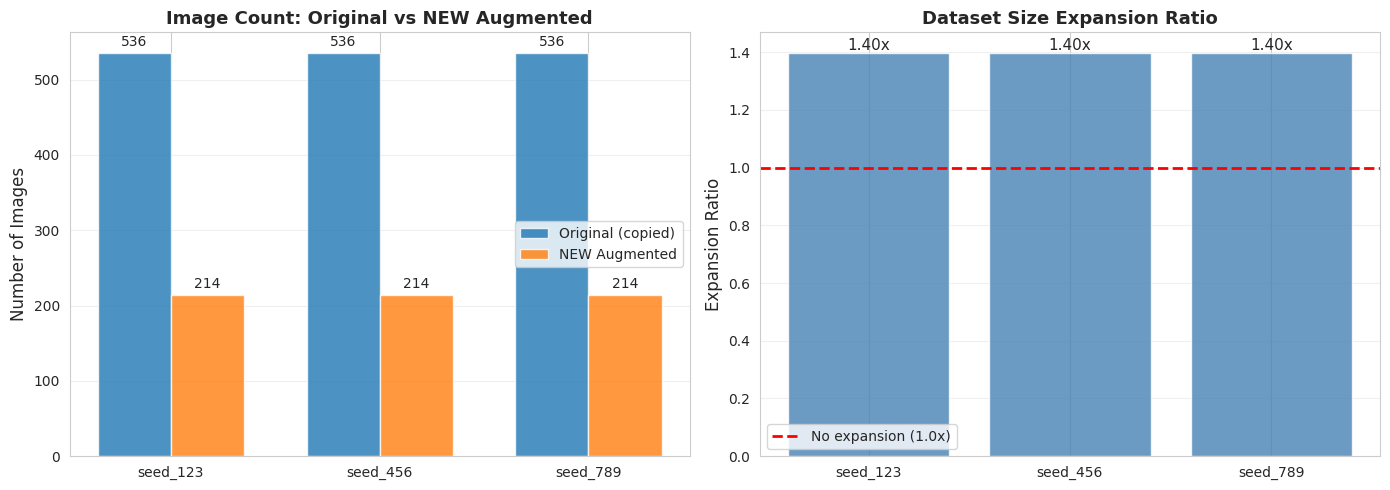

Image count visualization created


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Original vs Augmented Images
seeds_list = list(aug_image_counts.keys())
original_counts = [aug_image_counts[s]['original'] for s in seeds_list]
augmented_counts = [aug_image_counts[s]['augmented'] for s in seeds_list]

x = np.arange(len(seeds_list))
width = 0.35

ax = axes[0]
ax.bar(x - width/2, original_counts, width, label='Original (copied)', alpha=0.8)
ax.bar(x + width/2, augmented_counts, width, label='NEW Augmented', alpha=0.8)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Image Count: Original vs NEW Augmented', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(seeds_list)
ax.legend()
ax.grid(axis='y', alpha=0.3)

for i, (o, a) in enumerate(zip(original_counts, augmented_counts)):
    ax.text(i - width/2, o + 5, str(o), ha='center', va='bottom', fontsize=10)
    ax.text(i + width/2, a + 5, str(a), ha='center', va='bottom', fontsize=10)

# Plot 2: Dataset Size Expansion Ratio
total_counts = [aug_image_counts[s]['total'] for s in seeds_list]
ratios = [t / o for t, o in zip(total_counts, original_counts)]

ax = axes[1]
bars = ax.bar(seeds_list, ratios, alpha=0.8, color='steelblue')
ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='No expansion (1.0x)')
ax.set_ylabel('Expansion Ratio', fontsize=12)
ax.set_title('Dataset Size Expansion Ratio', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, ratio in zip(bars, ratios):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{ratio:.2f}x', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

print("Image count visualization created")

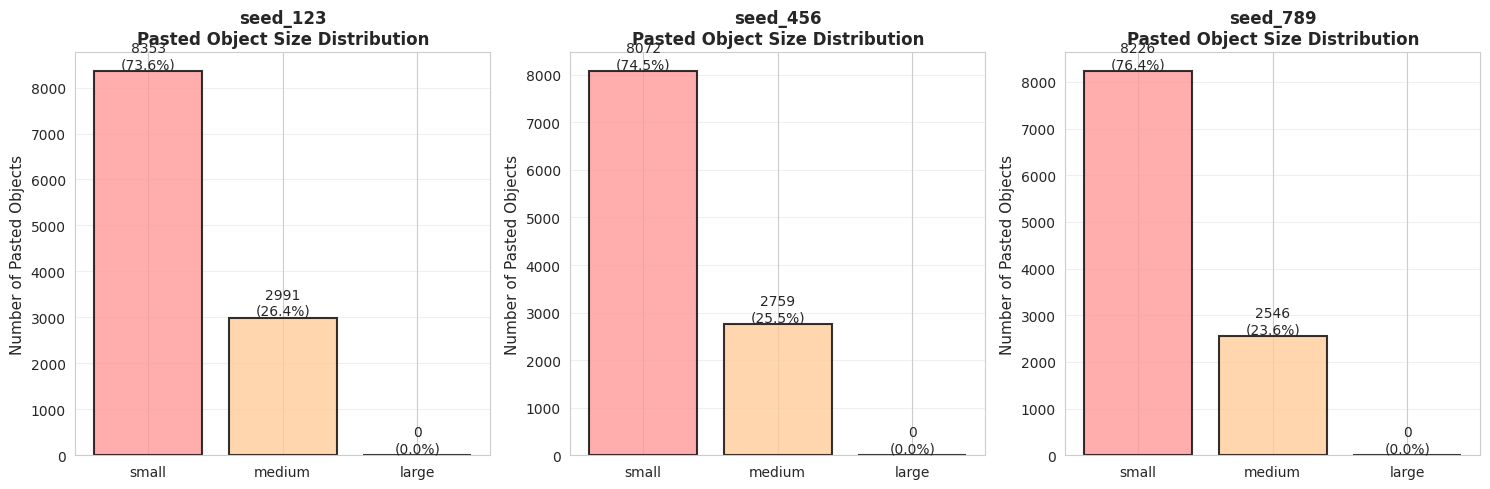

Object size distribution visualization created


In [40]:
fig, axes = plt.subplots(1, len(SEEDS), figsize=(5*len(SEEDS), 5))
if len(SEEDS) == 1:
    axes = [axes]

for idx, seed in enumerate(SEEDS):
    df = objects_analysis_all_seeds[seed]
    pasted_objects = df[df['is_augmented_image'] == True]
    
    if len(pasted_objects) > 0:
        size_counts = pasted_objects['size_category'].value_counts()
        size_order = ['small', 'medium', 'large']
        size_counts_ordered = [size_counts.get(cat, 0) for cat in size_order]
        
        ax = axes[idx]
        colors = ['#ff9999', '#ffcc99', '#99cc99']
        bars = ax.bar(size_order, size_counts_ordered, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
        
        ax.set_ylabel('Number of Pasted Objects', fontsize=11)
        ax.set_title(f'{seed}\nPasted Object Size Distribution', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        for bar in bars:
            height = bar.get_height()
            pct = height/len(pasted_objects)*100
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("Object size distribution visualization created")

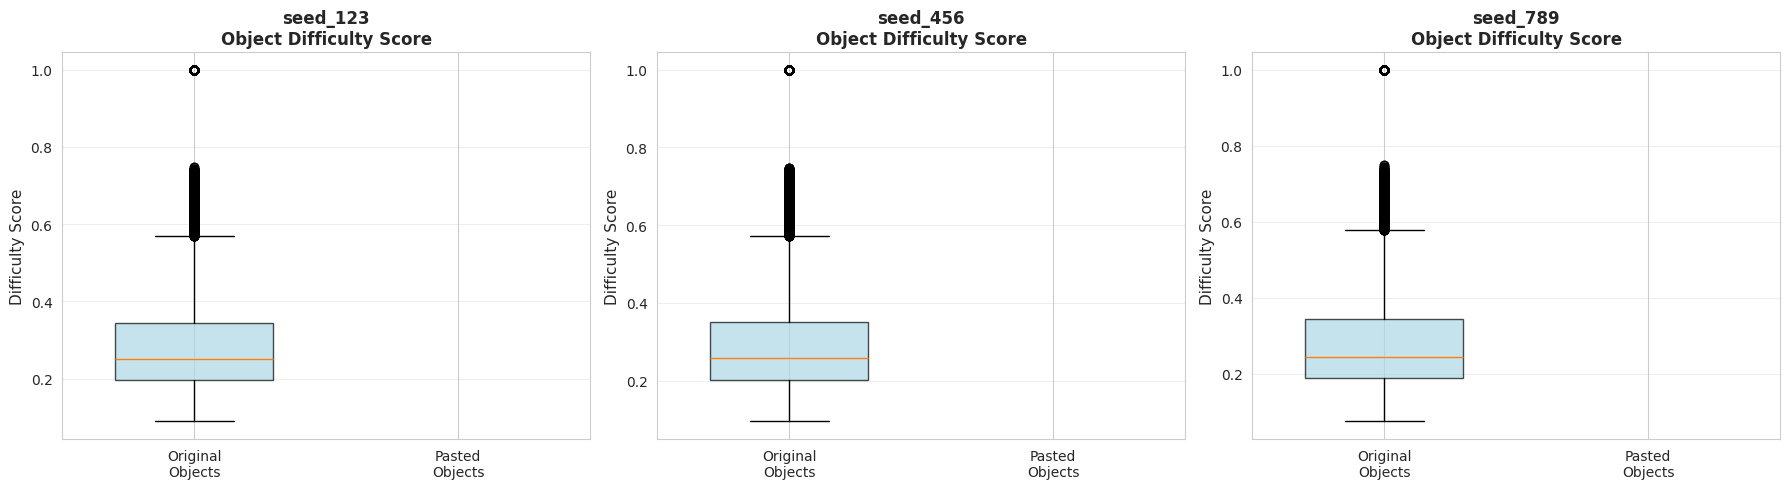

Object difficulty score visualization created


In [41]:
fig, axes = plt.subplots(1, len(SEEDS), figsize=(6*len(SEEDS), 5))
if len(SEEDS) == 1:
    axes = [axes]

for idx, seed in enumerate(SEEDS):
    difficulty_df = difficulty_scores_all_seeds[seed]
    objects_df = objects_analysis_all_seeds[seed]
    
    pasted_img_names = set(objects_df[objects_df['is_augmented_image']]['image_name'].unique())
    pasted_objs_diff = difficulty_df[difficulty_df['image_name'].isin(pasted_img_names)]['difficulty_score']
    original_objs_diff = difficulty_df[~difficulty_df['image_name'].isin(pasted_img_names)]['difficulty_score']
    
    ax = axes[idx]
    data_to_plot = [original_objs_diff, pasted_objs_diff]
    bp = ax.boxplot(data_to_plot, labels=['Original\nObjects', 'Pasted\nObjects'],
                     patch_artist=True, widths=0.6)
    
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Difficulty Score', fontsize=11)
    ax.set_title(f'{seed}\nObject Difficulty Score', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Object difficulty score visualization created")

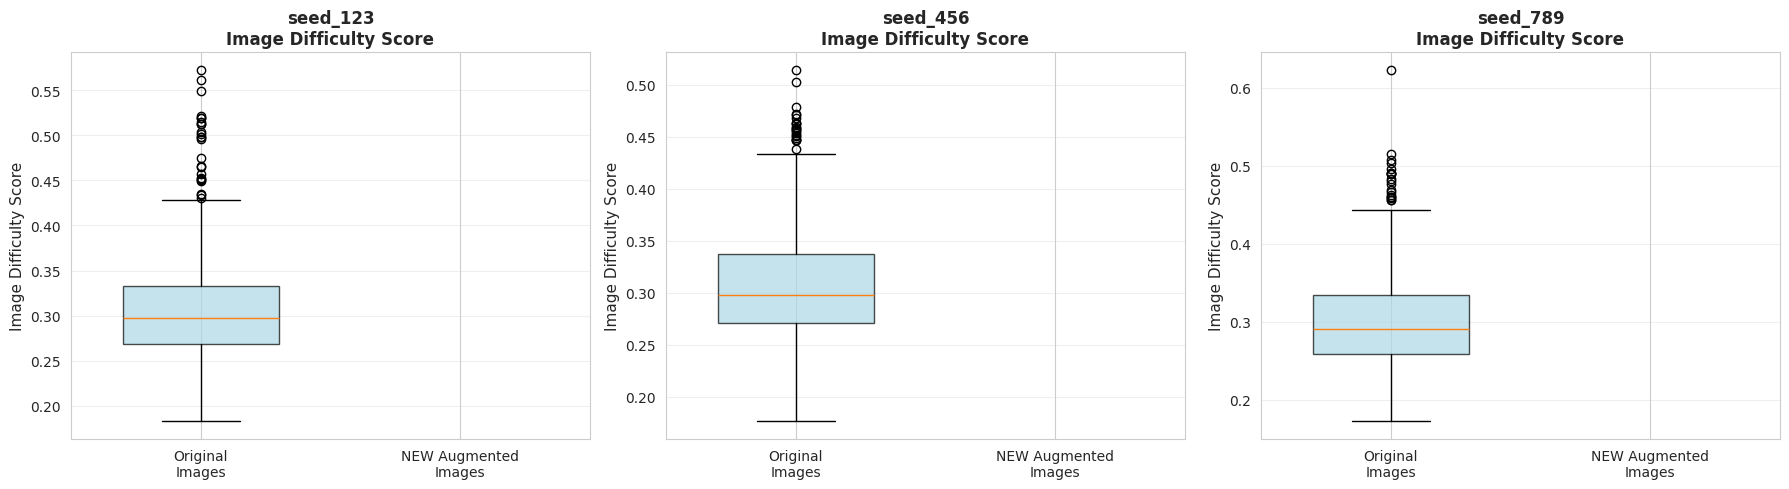

Image difficulty score visualization created


In [42]:
fig, axes = plt.subplots(1, len(SEEDS), figsize=(6*len(SEEDS), 5))
if len(SEEDS) == 1:
    axes = [axes]

for idx, seed in enumerate(SEEDS):
    scoring_results = scoring_results_all_seeds[seed]
    images_dir = RESULTS_DIR / seed / "Step_4_Copy_Paste_Augmentation" / "augmented_dataset" / "train" / "images"
    
    image_difficulties = []
    for image_diff in scoring_results["image_difficulties"]:
        image_path = Path(image_diff["image_path"])
        image_name = image_path.stem
        is_augmented = any(f.stem == image_name and f.name.startswith("aug_") 
                          for f in images_dir.glob("aug_*"))
        image_difficulties.append({"difficulty_score": image_diff["difficulty_score"], "is_augmented": is_augmented})
    
    img_df = pd.DataFrame(image_difficulties)
    original_img_diff = img_df[img_df['is_augmented'] == False]['difficulty_score']
    augmented_img_diff = img_df[img_df['is_augmented'] == True]['difficulty_score']
    
    ax = axes[idx]
    data_to_plot = [original_img_diff, augmented_img_diff]
    bp = ax.boxplot(data_to_plot, labels=['Original\nImages', 'NEW Augmented\nImages'],
                     patch_artist=True, widths=0.6)
    
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_ylabel('Image Difficulty Score', fontsize=11)
    ax.set_title(f'{seed}\nImage Difficulty Score', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Image difficulty score visualization created")